# Libraries

In [1]:
import os
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
import pydicom
import pandas as pd
from pydicom.multival import MultiValue
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
from torchvision import transforms, models
import csv
import timm
import torch.nn as nn
import torch.nn.functional as F
# optional: for AUC
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, matthews_corrcoef, roc_curve,
    brier_score_loss, balanced_accuracy_score, accuracy_score
)

In [2]:
# TRAIN_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_train.csv"
# VAL_CSV   = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_val.csv"
# TEST_CSV  = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_test.csv"


TRAIN_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_train_reduced.csv"
VAL_CSV   = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_val_reduced.csv"
TEST_CSV  = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_test_reduced.csv"

# ===============================
# Task configuration
# ===============================
# NUM_CLASSES = 4
# CLASS_NAMES = ["NORMAL", "DRUSEN", "DME", "CNV"]

NUM_CLASSES = 2
CLASS_NAMES = ["NORMAL", "DISEASE"]


# Label meaning:
# four_class_label:
# 0 -> NORMAL
# 1 -> DRUSEN
# 2 -> DME
# 3 -> CNV

# binary_label:
# 0 -> NORMAL
# 1 -> DISEASE (DRUSEN / DME / CNV)

# ===============================
# Training configuration (initial)
# ===============================
IMG_SIZE = 512        # standard for ResNet18
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 30

LR = 5e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
SEED = 42
set_seed(SEED)

# Dataset

In [4]:
# ===============================
# Load CSVs
# ===============================
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Test samples :", len(test_df))

# ===============================
# Check required columns
# ===============================
required_cols = [
    "new_file_path",
    "label_text",
    "three_class_label",
    "binary_label",
    "patient_id"
]

for col in required_cols:
    assert col in train_df.columns, f"Missing column in train_df: {col}"
    assert col in val_df.columns,  f"Missing column in val_df: {col}"
    assert col in test_df.columns,  f"Missing column in test_df: {col}"

print("✅ All required columns present")

# ===============================
# Class distribution
# ===============================
print("\nTrain distribution:")
print(train_df["label_text"].value_counts())

print("\nValidation distribution:")
print(val_df["label_text"].value_counts())

print("\nTest distribution:")
print(test_df["label_text"].value_counts())

# ===============================
# Peek at data
# ===============================
train_df.head()


Train samples: 1705
Val samples  : 656
Test samples : 646
✅ All required columns present

Train distribution:
label_text
Normal    962
AMD       413
DME       330
Name: count, dtype: int64

Validation distribution:
label_text
Normal    290
AMD       225
DME       141
Name: count, dtype: int64

Test distribution:
label_text
Normal    333
AMD       219
DME        94
Name: count, dtype: int64


,label_text,patient_id,new_file_path,three_class_label,binary_label,fold
0,Normal,NORMAL_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,0,0,0
1,Normal,NORMAL_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,0,0,0
2,Normal,NORMAL_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,0,0,0
3,Normal,NORMAL_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,0,0,0
4,Normal,NORMAL_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,0,0,0


In [5]:
# file_path = '/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/dhu_filtered.csv'
# import pandas as pd
# df = pd.read_csv(file_path)
# # 1. Identify unique patients and their specific category (AMD, DME, or NORMAL)
# # We use the first part of the patient_id string to identify the type
# patient_data = df.groupby('patient_id').first().reset_index()
# patient_data['category'] = patient_data['patient_id'].str.extract(r'([A-Za-z]+)')

# # Define the pool of patients
# all_patients = patient_data.copy()

# # 10 percent 

# # # 2. SELECT VALIDATION PATIENTS (1 Normal, 1 from AMD/DME pool)
# # val_normal = all_patients[all_patients['category'] == 'NORMAL'].sample(1, random_state=SEED)
# # val_abnormal = all_patients[all_patients['category'].isin(['AMD'])].sample(1, random_state=SEED)
# # val_dme    = all_patients[all_patients['category'] == 'DME'].sample(1, random_state=42)

# # val_list = pd.concat([val_normal, val_abnormal, val_dme])

# # # Remove validation from pool
# # pool_after_val = all_patients[~all_patients['patient_id'].isin(val_list['patient_id'])]

# # # 3. SELECT TRAINING PATIENTS (1 Normal, 1 AMD, 1 DME)
# # # Note: Using seed 42 as requested
# # train_normal = pool_after_val[pool_after_val['category'] == 'NORMAL'].sample(1, random_state=42)
# # train_amd    = pool_after_val[pool_after_val['category'] == 'AMD'].sample(1, random_state=42)
# # train_dme    = pool_after_val[pool_after_val['category'] == 'DME'].sample(1, random_state=42)
# # train_list   = pd.concat([train_normal, train_amd, train_dme])

# # 50 percent

# # 2. SELECT VALIDATION PATIENTS (1 Normal, 1 from AMD/DME pool)
# val_normal = all_patients[all_patients['category'] == 'NORMAL'].sample(2, random_state=SEED)
# val_abnormal = all_patients[all_patients['category'].isin(['AMD'])].sample(1, random_state=SEED)
# val_dme    = all_patients[all_patients['category'] == 'DME'].sample(1, random_state=42)

# val_list = pd.concat([val_normal, val_abnormal, val_dme])

# # Remove validation from pool
# pool_after_val = all_patients[~all_patients['patient_id'].isin(val_list['patient_id'])]

# # 3. SELECT TRAINING PATIENTS (1 Normal, 1 AMD, 1 DME)
# # Note: Using seed 42 as requested
# train_normal = pool_after_val[pool_after_val['category'] == 'NORMAL'].sample(6, random_state=42)
# train_amd    = pool_after_val[pool_after_val['category'] == 'AMD'].sample(4, random_state=42)
# train_dme    = pool_after_val[pool_after_val['category'] == 'DME'].sample(5, random_state=42)
# train_list   = pd.concat([train_normal, train_amd, train_dme])



# # 4. REMAINING ARE TEST
# test_list = pool_after_val[~pool_after_val['patient_id'].isin(train_list['patient_id'])]

# # 5. MAP BACK TO DATASET
# train_df = df[df['patient_id'].isin(train_list['patient_id'])].copy()
# val_df   = df[df['patient_id'].isin(val_list['patient_id'])].copy()
# test_df  = df[df['patient_id'].isin(test_list['patient_id'])].copy()

# # --- VERIFICATION ---
# print(f"Train Patients ({len(train_list)}): {train_list['patient_id'].tolist()}")
# print(f"Val Patients   ({len(val_list)}): {val_list['patient_id'].tolist()}")
# print(f"Test Patients  ({len(test_list)})")
# print("-" * 30)
# print(f"Image Counts -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# print(f"Total Samples: {len(df)}")
# print(f"Train Samples: {len(train_df)} ({len(train_df)/len(df):.1%})")
# print(f"Val Samples:   {len(val_df)} ({len(val_df)/len(df):.1%})")
# print(f"Test Samples:  {len(test_df)} ({len(test_df)/len(df):.1%})")


In [6]:
# # import pandas as pd
# from sklearn.model_selection import train_test_split

# # 1. Identify unique patients and their corresponding labels
# # We use the 'first' or 'mode' label for each patient to ensure stratification


# # 2. Load Dataset
# file_path = '/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/ucsd_filtered.csv'
# df = pd.read_csv(file_path)


# patient_data = df.groupby('patient_id')['binary_label'].agg(lambda x: x.mode()[0]).reset_index()

# # # 2. Split Patients: 10% (Train+Val) and 90% (Test)
# # train_val_patients, test_patients = train_test_split(
# #     patient_data, 
# #     test_size=0.90, 
# #     stratify=patient_data['binary_label'], 
# #     random_state=SEED
# # )

# train_val_patients, test_patients = train_test_split(
#     patient_data, 
#     test_size=0.50, 
#     stratify=patient_data['binary_label'], 
#     random_state=SEED
# )

# # 2. Split Patients: 15% (Train+Val) and 95% (Test)
# # train_val_patients, test_patients = train_test_split(
# #     patient_data, 
# #     test_size=0.95, 
# #     stratify=patient_data['binary_label'], 
# #     random_state=SEED
# # )

# # 3. Split the 10% Patient chunk into 8% Train and 2% Val (0.02/0.10 = 0.20)
# train_patients, val_patients = train_test_split(
#     train_val_patients, 
#     test_size=0.20, 
#     stratify=train_val_patients['binary_label'], 
#     random_state=SEED
# )

# # 4. Map the split patients back to the original full dataframe
# train_df = df[df['patient_id'].isin(train_patients['patient_id'])].copy()
# val_df   = df[df['patient_id'].isin(val_patients['patient_id'])].copy()
# test_df  = df[df['patient_id'].isin(test_patients['patient_id'])].copy()

# # --- Verification ---
# print(f"Total Patients: {len(patient_data)}")
# print(f"Train Patients: {len(train_patients)} | Val Patients: {len(val_patients)} | Test Patients: {len(test_patients)}")
# print("-" * 30)
# print(f"Total Samples: {len(df)}")
# print(f"Train Samples: {len(train_df)} ({len(train_df)/len(df):.1%})")
# print(f"Val Samples:   {len(val_df)} ({len(val_df)/len(df):.1%})")
# print(f"Test Samples:  {len(test_df)} ({len(test_df)/len(df):.1%})")

# # Check for leakage (should be 0)
# overlap = set(train_df['patient_id']).intersection(set(test_df['patient_id']))
# print(f"\nPatient ID Overlap between Train and Test: {len(overlap)}")

In [7]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# import numpy as np
# import random
# import torch

# # 1. Set Seed for Reproducibility
# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     if torch.cuda.is_available():
#         torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

# SEED = 42
# set_seed(SEED)

# # 2. Load Dataset
# file_path = '/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/octC8_filtered.csv'
# df = pd.read_csv(file_path)

# # 3. Split the entire data into 10% (for train+val) and 90% (for test)

# # This ensures 90% of the total data goes to test_df
# # train_val_df, test_df = train_test_split(
# #     df, 
# #     test_size=0.90, 
# #     stratify=df['binary_label'], 
# #     random_state=SEED
# # )
# train_val_df, test_df = train_test_split(
#     df, 
#     test_size=0.50, 
#     stratify=df['binary_label'], 
#     random_state=SEED
# )


# # This ensures 95% of the total data goes to test_df
# # train_val_df, test_df = train_test_split(
# #     df, 
# #     test_size=0.95, 
# #     stratify=df['binary_label'], 
# #     random_state=SEED
# # )

# # 4. Split the 10% chunk into 8% Train and 2% Val
# # Note: 2% of total is 20% of this 10% chunk (0.02 / 0.10 = 0.20)
# train_df, val_df = train_test_split(
#     train_val_df, 
#     test_size=0.20, 
#     stratify=train_val_df['binary_label'], 
#     random_state=SEED
# )

# # Verification
# print(f"Total samples: {len(df)}")
# print(f"Train size (8%): {len(train_df)}")
# print(f"Val size   (2%): {len(val_df)}")
# print(f"Test size (90%): {len(test_df)}")

# # Check label distribution
# print("\nLabel Distribution (should be ~52.7% label 1):")
# print(f"Train: \n{train_df['binary_label'].value_counts()}")
# print(f"Val: \n{val_df['binary_label'].value_counts()}")

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the data
file_path = '/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/dhu_filtered.csv'
df = pd.read_csv(file_path)

# 2. First Split: Separate the 95% test set from the 5% "remainder"
# Stratify ensures both sets have the same % of positive/negative cases
df_temp, test_df = train_test_split(
    df, 
    test_size=0.95, 
    stratify=df['binary_label'], 
    random_state=42
)

# 3. Second Split: Split the 5% remainder into Train (4%) and Valid (1%)
# Since 1% is 1/5 of the temp set, we use test_size=0.2 (20% of 5% = 1%)
train_df, val_df = train_test_split(
    df_temp, 
    test_size=0.20, 
    stratify=df_temp['binary_label'], 
    random_state=42
)

# 4. Print the distributions
def print_dist(name, d):
    counts = d['binary_label'].value_counts()
    percents = d['binary_label'].value_counts(normalize=True) * 100
    print(f"--- {name} ({len(d)} samples) ---")
    for val in counts.index:
        print(f"Label {val}: {counts[val]} ({percents[val]:.2f}%)")
    print()

print_dist("Train Set (4%)", train_df)
print_dist("Valid Set (1%)", val_df)
print_dist("Test Set (95%)", test_df)

--- Train Set (4%) (114 samples) ---
Label 1: 58 (50.88%)
Label 0: 56 (49.12%)

--- Valid Set (1%) (29 samples) ---
Label 1: 15 (51.72%)
Label 0: 14 (48.28%)

--- Test Set (95%) (2722 samples) ---
Label 1: 1385 (50.88%)
Label 0: 1337 (49.12%)



In [9]:
print(train_df['binary_label'].value_counts())
print(val_df['binary_label'].value_counts())
print(test_df['binary_label'].value_counts())

binary_label
1    58
0    56
Name: count, dtype: int64
binary_label
1    15
0    14
Name: count, dtype: int64
binary_label
1    1385
0    1337
Name: count, dtype: int64


In [10]:
from PIL import Image, ImageFile
import torch

ImageFile.LOAD_TRUNCATED_IMAGES = True

class NEHOCTDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            img = Image.open(row["new_file_path"])

            # Ensure 3-channel RGB
            if img.mode != "RGB":
                img = img.convert("RGB")

        except Exception as e:
            raise RuntimeError(
                f"Failed to load image: {row['new_file_path']}"
            ) from e

        label = int(row[self.label_col])

        # if self.transform:
        #     img = self.transform(img)

        return img, label


def pil_collate_fn(batch):
    """
    batch: list of (PIL_image, label)
    returns:
        images: list[PIL.Image]
        labels: torch.LongTensor
    """
    images, labels = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.long)
    return list(images), labels

# class AddGaussianNoise(object):
#     def __init__(self, mean=0.0, std=0.02):
#         self.mean = mean
#         self.std = std

#     def __call__(self, tensor):
#         noise = torch.randn_like(tensor) * self.std + self.mean
#         return torch.clamp(tensor + noise, 0.0, 1.0)

# class AddSpeckleNoise(object):
#     def __init__(self, std=0.02):
#         self.std = std

#     def __call__(self, tensor):
#         noise = torch.randn_like(tensor) * self.std
#         return torch.clamp(tensor + tensor * noise, 0.0, 1.0)

class AddSpeckleNoise(object):
    def __init__(self, std=0.01):
        self.std = std

    def __call__(self, tensor):
        if self.std <= 0:
            return tensor
        noise = torch.randn_like(tensor) * self.std
        out = tensor + tensor * noise
        return torch.clamp(out, 0.0, 1.0)



In [11]:
# train_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),
# ])

# train_transform_sub = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomResizedCrop(
#         IMG_SIZE,
#         scale=(0.9, 1.0),
#         ratio=(0.95, 1.05)
#     ),
#     transforms.RandomHorizontalFlip(p=0.5),

#     transforms.ToTensor(),

#     # AddGaussianNoise(std=0.02),
#     AddSpeckleNoise(std=0.02),

#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     ),
# ])

# val_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),
# ])

# test_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225]),
# ])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Safe for OCT + Mammogram
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# train_transform_sub = transforms.Compose([
#     transforms.RandomChoice([
#         transforms.Resize((IMG_SIZE, IMG_SIZE)),
#         transforms.Resize((int(0.9 * IMG_SIZE), int(0.9 * IMG_SIZE))),
#         transforms.Resize((int(0.8 * IMG_SIZE), int(0.8 * IMG_SIZE))),
#     ]),

#     # Restore to network input size
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),

#     transforms.RandomHorizontalFlip(p=0.5),

#     transforms.ToTensor(),

#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     ),
# ])

train_transform_sub = transforms.Compose([
    transforms.RandomChoice([
        transforms.Resize((int(0.9 * IMG_SIZE), int(0.9 * IMG_SIZE))),
        transforms.Resize((int(0.85 * IMG_SIZE), int(0.85 * IMG_SIZE))),
        transforms.Resize((int(0.8 * IMG_SIZE), int(0.8 * IMG_SIZE))),
    ]),

    # Restore to network input size
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.RandomApply(
        [AddSpeckleNoise(std=0.01)],
        p=0.3
    ),
    
    # AddSpeckleNoise(std=0.01),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


In [12]:
# import os
# TEST_CSV = "4096_3328_SD_imbalanced_val_15.csv"
# ROOT = "/media/miglab/DATA_20TB1/Datasets/EMBED"
# df = pd.read_csv(TEST_CSV)
# df["new_file_path"] = df["anon_dicom_path"].apply(
#     lambda x: os.path.join(ROOT, x) if pd.notna(x) else x
# )
# df.to_csv(TEST_CSV, index=False)

In [13]:
train_dataset = NEHOCTDataset(train_df, label_col='binary_label')
val_dataset   = NEHOCTDataset(val_df, label_col='binary_label')
test_dataset  = NEHOCTDataset(test_df, label_col='binary_label')

pinmem = True if torch.cuda.is_available() else False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pinmem, collate_fn=pil_collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pinmem, collate_fn=pil_collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pinmem, collate_fn=pil_collate_fn)

In [14]:
# next(iter(train_loader))


In [15]:
# import matplotlib.pyplot as plt

# IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
# IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# def denormalize(img):
#     """
#     img: Tensor [3, H, W] after Normalize
#     """
#     return img * IMAGENET_STD + IMAGENET_MEAN
# def visualize_dataloader_batch(
#     dataloader,
#     transform,
#     num_images=4,
#     title="DataLoader Visualization",
# ):
#     """
#     Visualize images exactly as seen by the model AFTER transform.

#     dataloader : DataLoader with pil_collate_fn
#     transform  : torchvision transform to apply (train / sub / val / test)
#     """
#     imgs_pil, labels = next(iter(dataloader))

#     num_images = min(num_images, len(imgs_pil))

#     plt.figure(figsize=(4 * num_images, 4))

#     for i in range(num_images):
#         # Apply transform (this is what the model sees)
#         img = transform(imgs_pil[i])  # Tensor [3,H,W]

#         # Denormalize
#         img = img.cpu()
#         img = img * IMAGENET_STD + IMAGENET_MEAN
#         img = img.clamp(0, 1)

#         plt.subplot(1, num_images, i + 1)
#         plt.imshow(img.permute(1, 2, 0))
#         plt.title(f"Label: {labels[i].item()}")
#         plt.axis("off")

#     plt.suptitle(title, fontsize=14)
#     plt.tight_layout()
#     plt.show()

In [16]:
# visualize_dataloader_batch(
#     train_loader,
#     transform=train_transform_sub,
#     num_images=8,
#     title="Train – GradAug Sub-network View"
# )

# Metrics

In [17]:
def compute_uncertainty_stats(y_proba: np.ndarray, y_true: np.ndarray):
    y_proba = np.asarray(y_proba, dtype=np.float64)
    y_true  = np.asarray(y_true, dtype=np.int64)

    y_proba = np.nan_to_num(y_proba, nan=0.5, posinf=1.0, neginf=0.0)

    eps = 1e-8
    p1 = np.clip(y_proba, eps, 1.0 - eps)
    p0 = 1.0 - p1

    entropy = -(p0 * np.log(p0) + p1 * np.log(p1))
    confidence = np.maximum(p0, p1)
    uncertainty = 1.0 - confidence

    out = {
        "avg_entropy": float(np.mean(entropy)),
        "entropy_std": float(np.std(entropy)),
        "avg_uncertainty": float(np.mean(uncertainty)),
        "uncertainty_std": float(np.std(uncertainty)),
    }

    # ---- class-conditional statistics ----
    for cls in (0, 1):
        mask = (y_true == cls)

        if mask.any():
            out[f"entropy_class{cls}_avg"] = float(entropy[mask].mean())
            out[f"entropy_class{cls}_std"] = float(entropy[mask].std())
            out[f"uncertainty_class{cls}_avg"] = float(uncertainty[mask].mean())
            out[f"uncertainty_class{cls}_std"] = float(uncertainty[mask].std())
        else:
            out[f"entropy_class{cls}_avg"] = float("nan")
            out[f"entropy_class{cls}_std"] = float("nan")
            out[f"uncertainty_class{cls}_avg"] = float("nan")
            out[f"uncertainty_class{cls}_std"] = float("nan")

    return out

In [18]:
def compute_binary_class_weights(df):
    counts = df["binary_label"].value_counts().sort_index().values
    total = counts.sum()
    weights = total / (2.0 * counts)
    return torch.tensor(weights, dtype=torch.float)

class_weights = compute_binary_class_weights(train_df).to(DEVICE)

print("Class counts:")
print(train_df["binary_label"].value_counts().sort_index())

print("Class weights:", class_weights.cpu().numpy())

Class counts:
binary_label
0    56
1    58
Name: count, dtype: int64
Class weights: [1.0178572  0.98275864]


In [19]:
# import csv
# import os

# CSV_HEADER = [
#     "epoch",
#     "train_loss", "val_loss", "test_loss",
#     "train_acc", "val_acc", "test_acc",
#     "train_auc", "val_auc", "test_auc",
#     "val_pr_auc", "test_pr_auc",
#     "val_f1", "test_f1", "val_macro_f1", "test_macro_f1",
#     "val_precision", "val_recall", "val_npv",
#     "test_precision", "test_recall", "test_npv",
#     "val_specificity", "test_specificity",
#     "val_sens_at_spec_90", "test_sens_at_spec_90",
#     "avg_entropy", "entropy_std",
#     "avg_uncertainty", "uncertainty_std",
#     "entropy_class0_avg", "entropy_class0_std",
#     "entropy_class1_avg", "entropy_class1_std",
#     "uncertainty_class0_avg", "uncertainty_class0_std",
#     "uncertainty_class1_avg", "uncertainty_class1_std",
#     "tn", "fp", "fn", "tp", "n_samples"
# ]

# def append_metrics_to_csv(csv_path, row_dict, float_fmt="{:.6f}"):
#     """
#     Appends one epoch of metrics to CSV.
#     Floats are formatted to fixed precision (default .6f).
#     Creates file + header if missing.
#     """
#     file_exists = os.path.isfile(csv_path)

#     formatted_row = {}
#     for k, v in row_dict.items():
#         if isinstance(v, float):
#             if np.isnan(v):
#                 formatted_row[k] = np.nan
#             else:
#                 formatted_row[k] = float_fmt.format(v)
#         else:
#             formatted_row[k] = v

#     with open(csv_path, mode="a", newline="") as f:
#         writer = csv.DictWriter(f, fieldnames=CSV_HEADER)

#         if not file_exists:
#             writer.writeheader()

#         writer.writerow({k: formatted_row.get(k, np.nan) for k in CSV_HEADER})

In [20]:
import csv
import os

CSV_HEADER = [
    "epoch",
    "train_loss", "val_loss",
    "train_acc", "val_acc", 
    "train_auc", "val_auc",
    "val_f1", "val_macro_f1",  
    # "avg_entropy", "entropy_std",
    # "avg_uncertainty", "uncertainty_std",
    # "entropy_class0_avg", "entropy_class0_std",
    # "entropy_class1_avg", "entropy_class1_std",
    # "uncertainty_class0_avg", "uncertainty_class0_std",
    # "uncertainty_class1_avg", "uncertainty_class1_std",
    # "tn", "fp", "fn", "tp", "n_samples"
]

def append_metrics_to_csv(csv_path, row_dict, float_fmt="{:.6f}"):
    """
    Appends one epoch of metrics to CSV.
    Floats are formatted to fixed precision (default .6f).
    Creates file + header if missing.
    """
    file_exists = os.path.isfile(csv_path)

    formatted_row = {}
    for k, v in row_dict.items():
        if isinstance(v, float):
            if np.isnan(v):
                formatted_row[k] = np.nan
            else:
                formatted_row[k] = float_fmt.format(v)
        else:
            formatted_row[k] = v

    with open(csv_path, mode="a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_HEADER)

        if not file_exists:
            writer.writeheader()

        writer.writerow({k: formatted_row.get(k, np.nan) for k in CSV_HEADER})

In [21]:
def compute_binary_metrics(y_proba, y_true, threshold=0.5, target_spec=0.90):
    """
    y_proba: list or np.array of predicted probability for class 1
    y_true:  list or np.array of integer {0,1}
    threshold: float for converting proba -> label
    returns: dict of metrics including confusion matrix entries
    """
    y_proba = np.asarray(y_proba)
    y_true = np.asarray(y_true).astype(int)

    out = {}
    # ROC-AUC and PR-AUC (handle single-class edge)
    try:
        out['roc_auc'] = float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) > 1 else float("nan")
    except Exception:
        out['roc_auc'] = float("nan")
    try:
        out['pr_auc'] = float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) > 1 else float("nan")
    except Exception:
        out['pr_auc'] = float("nan")

    # Binary predictions
    y_pred = (y_proba >= threshold).astype(int)

    # Standard metrics
    out['precision'] = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    out['recall'] = float(recall_score(y_true, y_pred, average="macro", zero_division=0))    # sensitivity
    out['f1'] = float(f1_score(y_true, y_pred, zero_division=0))
    out['macro_f1'] = float(
        f1_score(y_true, y_pred, average="macro", zero_division=0)
    )
    out['balanced_acc'] = float(balanced_accuracy_score(y_true, y_pred))
    # MCC (may raise if degenerate)
    # try:
    #     out['mcc'] = float(matthews_corrcoef(y_true, y_pred))
    # except Exception:
    #     out['mcc'] = float("nan")

    # Confusion matrix
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        out['tn'] = int(tn); out['fp'] = int(fp); out['fn'] = int(fn); out['tp'] = int(tp)
        out['specificity'] = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
        out['sensitivity'] = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
        out['npv'] = float(tn / (tn + fn)) if (tn + fn) > 0 else float("nan")

    except Exception:
        out['tn'] = out['fp'] = out['fn'] = out['tp'] = 0
        out['specificity'] = out['sensitivity'] = float("nan")

    # Brier score
    try:
        out['brier'] = float(brier_score_loss(y_true, y_proba))
    except Exception:
        out['brier'] = float("nan")

    out['n_samples'] = int(len(y_true))
    out['threshold'] = float(threshold)
    try:
        thresh_list = np.linspace(0, 1, 200)
        best_sens = float("nan")
        best_thr = float("nan")

        for thr in thresh_list:
            yp = (y_proba >= thr).astype(int)
            cm = confusion_matrix(y_true, yp, labels=[0,1])
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
            sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

            if not np.isnan(spec) and spec >= target_spec:
                # choose largest sensitivity among valid thresholds
                if np.isnan(best_sens) or sens > best_sens:
                    best_sens = sens
                    best_thr = thr

        out["sens_at_spec"] = best_sens
        out["thr_at_spec"] = best_thr
        out["target_spec"] = target_spec

    except Exception:
        out["sens_at_spec"] = float("nan")
        out["thr_at_spec"] = float("nan")
        out["target_spec"] = target_spec
    
    try:
        u_stats = compute_uncertainty_stats(y_proba, y_true)
        out.update(u_stats)
    except Exception:
        for k in [
            "avg_entropy","entropy_std",
            "avg_uncertainty","uncertainty_std",
            "entropy_class0_avg","entropy_class0_std",
            "entropy_class1_avg","entropy_class1_std",
            "uncertainty_class0_avg","uncertainty_class0_std",
            "uncertainty_class1_avg","uncertainty_class1_std",
        ]:
            out[k] = float("nan")
    return out

def print_epoch_summary(epoch, train_loss, val_loss, test_loss, train_auc, val_auc, test_auc, train_acc, val_acc, val_macro_f1):
    print("=" * 90)
    print(f"Epoch {epoch}")
    print("-" * 90)
    print(f"Train | Loss={(train_loss):.4f}  AUC={(train_auc):.4f}  Acc={(train_acc):.4f}")
    print(f"Val   | Loss={(val_loss):.4f}  AUC={(val_auc):.4f}  Acc={(val_acc):.4f}")
    print("Val Macro F1: {:.4f}".format(val_macro_f1))

    print("\nClassification Metrics:")
    print("=" * 90)

In [22]:
# def compute_binary_metrics(y_proba, y_true, threshold=0.5, target_spec=0.90):
#     """
#     y_proba: list or np.array of predicted probability for class 1
#     y_true:  list or np.array of integer {0,1}
#     threshold: float for converting proba -> label
#     returns: dict of metrics including confusion matrix entries
#     """
#     y_proba = np.asarray(y_proba)
#     y_true = np.asarray(y_true).astype(int)

#     out = {}
#     # ROC-AUC and PR-AUC (handle single-class edge)
#     try:
#         out['roc_auc'] = float(roc_auc_score(y_true, y_proba)) if len(np.unique(y_true)) > 1 else float("nan")
#     except Exception:
#         out['roc_auc'] = float("nan")
#     try:
#         out['pr_auc'] = float(average_precision_score(y_true, y_proba)) if len(np.unique(y_true)) > 1 else float("nan")
#     except Exception:
#         out['pr_auc'] = float("nan")

#     # Binary predictions
#     y_pred = (y_proba >= threshold).astype(int)

#     # Standard metrics
#     out['precision'] = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
#     out['recall'] = float(recall_score(y_true, y_pred, average="macro", zero_division=0))    # sensitivity
#     out['f1'] = float(f1_score(y_true, y_pred, zero_division=0))
#     out['macro_f1'] = float(
#         f1_score(y_true, y_pred, average="macro", zero_division=0)
#     )
#     out['balanced_acc'] = float(balanced_accuracy_score(y_true, y_pred))
#     # MCC (may raise if degenerate)
#     # try:
#     #     out['mcc'] = float(matthews_corrcoef(y_true, y_pred))
#     # except Exception:
#     #     out['mcc'] = float("nan")

#     # Confusion matrix
#     try:
#         tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
#         out['tn'] = int(tn); out['fp'] = int(fp); out['fn'] = int(fn); out['tp'] = int(tp)
#         out['specificity'] = float(tn / (tn + fp)) if (tn + fp) > 0 else float("nan")
#         out['sensitivity'] = float(tp / (tp + fn)) if (tp + fn) > 0 else float("nan")
#         out['npv'] = float(tn / (tn + fn)) if (tn + fn) > 0 else float("nan")

#     except Exception:
#         out['tn'] = out['fp'] = out['fn'] = out['tp'] = 0
#         out['specificity'] = out['sensitivity'] = float("nan")

#     # Brier score
#     try:
#         out['brier'] = float(brier_score_loss(y_true, y_proba))
#     except Exception:
#         out['brier'] = float("nan")

#     out['n_samples'] = int(len(y_true))
#     out['threshold'] = float(threshold)
#     try:
#         thresh_list = np.linspace(0, 1, 200)
#         best_sens = float("nan")
#         best_thr = float("nan")

#         for thr in thresh_list:
#             yp = (y_proba >= thr).astype(int)
#             cm = confusion_matrix(y_true, yp, labels=[0,1])
#             tn, fp, fn, tp = cm.ravel()
#             spec = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
#             sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

#             if not np.isnan(spec) and spec >= target_spec:
#                 # choose largest sensitivity among valid thresholds
#                 if np.isnan(best_sens) or sens > best_sens:
#                     best_sens = sens
#                     best_thr = thr

#         out["sens_at_spec"] = best_sens
#         out["thr_at_spec"] = best_thr
#         out["target_spec"] = target_spec

#     except Exception:
#         out["sens_at_spec"] = float("nan")
#         out["thr_at_spec"] = float("nan")
#         out["target_spec"] = target_spec
    
#     try:
#         u_stats = compute_uncertainty_stats(y_proba, y_true)
#         out.update(u_stats)
#     except Exception:
#         for k in [
#             "avg_entropy","entropy_std",
#             "avg_uncertainty","uncertainty_std",
#             "entropy_class0_avg","entropy_class0_std",
#             "entropy_class1_avg","entropy_class1_std",
#             "uncertainty_class0_avg","uncertainty_class0_std",
#             "uncertainty_class1_avg","uncertainty_class1_std",
#         ]:
#             out[k] = float("nan")
#     return out

# def print_epoch_summary(epoch, train_loss, val_loss, test_loss, train_auc, val_auc, test_auc, train_acc, val_acc, test_acc, metrics, uncert):
#     print("=" * 90)
#     print(f"Epoch {epoch}")
#     print("-" * 90)
#     print(f"Train | Loss={(train_loss):.4f}  AUC={(train_auc):.4f}  Acc={(train_acc):.4f}")
#     print(f"Val   | Loss={(val_loss):.4f}  AUC={(val_auc):.4f}  Acc={(val_acc):.4f}")
#     print(f"Test  | Loss={(test_loss):.4f}  AUC={(test_auc):.4f}  Acc={(test_acc):.4f}")

#     print("\nClassification Metrics:")
#     print(
#         f"  ROC-AUC={(metrics['roc_auc']):.4f}  PR-AUC={(metrics['pr_auc']):.4f}  Brier_score={(metrics['brier']):.4f}  "
#         f"F1={(metrics['f1']):.4f}  Macro-F1={(metrics['macro_f1']):.4f}  Precision={(metrics['precision']):.4f}  Recall={(metrics['recall']):.4f}  NPV={(metrics['npv']):.4f}" f"  Specificity={(metrics['specificity']):.4f}  "  f"Sens@Spec90={(metrics['sens_at_spec']):.4f} ")

#     print("\nUncertainty Metrics:")
#     print(
#         f"  AvgEntropy={(uncert['avg_entropy']):.4f} ± {(uncert['entropy_std']):.4f} | " f"AvgUncertainty={(uncert['avg_uncertainty']):.4f} ± {(uncert['uncertainty_std']):.4f}" f"  Entropy(C0)={(uncert['entropy_class0_avg']):.4f}  " f"Entropy(C1)={(uncert['entropy_class1_avg']):.4f}" f"  Uncertainty(C0)={(uncert['uncertainty_class0_avg']):.4f}  " f"Uncertainty(C1)={(uncert['uncertainty_class1_avg']):.4f}"
#     )

#     print("\nConfusion Matrix:" f"  TP={metrics['tp']}  FP={metrics['fp']} " f"FN={metrics['fn']}  TN={metrics['tn']}")
#     print("=" * 90)

# Model

In [23]:
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4   # 🔑 always used

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

        # number of blocks before layer4
        self.n_pre_blocks = (
            len(self.layer1)
            + len(self.layer2)
            + len(self.layer3)
        )

    def forward_full(self, x):
        x = self._forward_stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self._head(x)

    def forward_subnet(self, x, keep_ratio):
        """
        keep_ratio applies ONLY to blocks before layer4
        """
        n_keep = int(self.n_pre_blocks * keep_ratio)
        n_keep = max(1, n_keep)

        x = self._forward_stem(x)

        blocks = []
        for layer in [self.layer1, self.layer2, self.layer3]:
            for block in layer:
                blocks.append(block)

        for i in range(n_keep):
            x = blocks[i](x)

        x = self.layer4(x)   # 🔑 ALWAYS include
        return self._head(x)

    def _forward_stem(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        return x

    def _head(self, x):
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

def sample_keep_ratio():
    return np.random.uniform(0.8, 0.99)

model = ResNet34GradAug(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
model = model.to(DEVICE)

/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
criterion = nn.CrossEntropyLoss(weight=class_weights).to(DEVICE)

optimizer = torch.optim.AdamW(
    [
        # Stem
        {"params": model.conv1.parameters(), "lr": 1e-4},
        {"params": model.bn1.parameters(),   "lr": 1e-4},

        # Residual layers
        {"params": model.layer1.parameters(), "lr": 1e-4},
        {"params": model.layer2.parameters(), "lr": 1e-4},
        {"params": model.layer3.parameters(), "lr": 1e-4},
        {"params": model.layer4.parameters(), "lr": 1e-4},

        # Classification head
        {"params": model.fc.parameters(),     "lr": 3e-4},
    ],
    weight_decay=1e-4
)
# optimizer = torch.optim.AdamW(
#     [
#         # Stem
#         {"params": model.conv1.parameters(), "lr": 5e-4},
#         {"params": model.bn1.parameters(),   "lr": 5e-4},

#         # Residual layers
#         {"params": model.layer1.parameters(), "lr": 5e-4},
#         {"params": model.layer2.parameters(), "lr": 5e-4},
#         {"params": model.layer3.parameters(), "lr": 5e-4},
#         {"params": model.layer4.parameters(), "lr": 5e-4},

#         # Classification head
#         {"params": model.fc.parameters(),     "lr": 7e-4},
#     ],
#     weight_decay=1e-4
# )

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6)

def kl_loss(student_logits, teacher_logits):
    return F.kl_div(
        F.log_softmax(student_logits, dim=1),
        F.softmax(teacher_logits.detach(), dim=1),
        reduction="batchmean"
    )

def set_bn_running_stats(model, flag):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.track_running_stats = flag

# Loops

In [25]:
def train(
    model,
    loader,
    optimizer,
    device,
    criterion,
    train_tf_full,
    train_tf_sub,
    epoch,
    n_views=2,
    lambda_kl=0.02,
    warmup_epochs=5
):
    model.train()
    epoch_loss = 0.0
    probs, targets = [], []

    kl_weight = lambda_kl * min(1.0, epoch / 10)
    
    for imgs_pil, y in tqdm(loader, desc="Train", leave=False):
        y = y.to(device)
        set_bn_running_stats(model, True)
        # -------- Teacher (full net) --------
        imgs_full = torch.stack([train_tf_full(img) for img in imgs_pil]).to(device)

        optimizer.zero_grad()
        logits_full = model.forward_full(imgs_full)
        loss = criterion(logits_full, y)

        teacher_probs = F.softmax(logits_full.detach(), dim=1)
        teacher_probs = torch.clamp(teacher_probs, 1e-4, 1.0 - 1e-4)

        # -------- Subnets --------
        if epoch > warmup_epochs:
            set_bn_running_stats(model, False)

            for _ in range(n_views):
                keep_ratio = sample_keep_ratio()

                imgs_sub = torch.stack(
                    [train_tf_sub(img) for img in imgs_pil]
                ).to(device)

                with torch.enable_grad():
                    logits_sub = model.forward_subnet(imgs_sub, keep_ratio)

                loss_kl = F.kl_div(
                    F.log_softmax(logits_sub, dim=1),
                    teacher_probs,
                    reduction="batchmean"
                )

                loss += (kl_weight / n_views) * loss_kl
            set_bn_running_stats(model, True)
       
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        epoch_loss += loss.item()
        probs.extend(teacher_probs[:, 1].cpu().numpy())
        targets.extend(y.cpu().numpy())

    epoch_loss /= len(loader)
    auc = roc_auc_score(targets, probs)
    acc = np.mean((np.array(probs) >= 0.5) == np.array(targets))
    return epoch_loss, auc, acc

In [26]:
@torch.no_grad()
def validate(
    model,
    loader,
    device,
    criterion,
    val_transform
):
    model.eval()

    probs, targets = [], []
    epoch_loss = 0.0
    c=0
    for imgs_pil, y in tqdm(loader, desc="Val", leave=False):
        y = y.to(device)

        imgs = torch.stack(
            [val_transform(img) for img in imgs_pil]
        ).to(device)

        logits = model.forward_full(imgs)
        loss = criterion(logits, y)

        p = F.softmax(logits, dim=1)

        epoch_loss += loss.item()
        probs.extend(p[:, 1].cpu().numpy())
        targets.extend(y.cpu().numpy())
       
    epoch_loss /= len(loader)
    
    metrics = compute_binary_metrics(probs, targets)
    acc = np.mean((np.array(probs) >= 0.5) == np.array(targets))
    auc = roc_auc_score(targets, probs)

    return epoch_loss, metrics, acc, auc, probs, targets


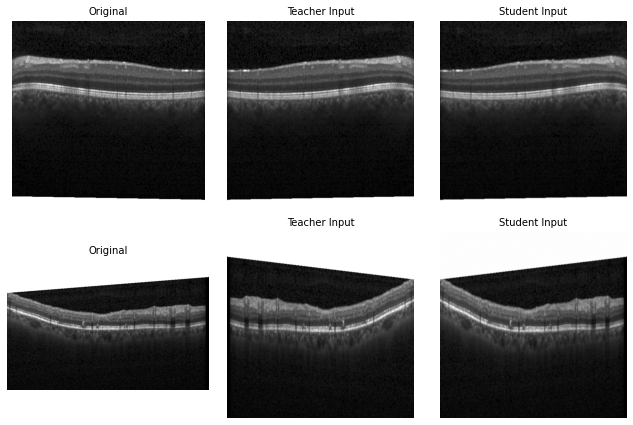

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

def denormalize(tensor, mean, std):
    """Undo normalization for visualization"""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

# Grab one batch from trainloader
imgs_pil_batch, labels_batch = next(iter(test_loader))

# Pick two random samples from batch
indices = random.sample(range(len(imgs_pil_batch)), 2)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for row, idx in enumerate(indices):
    img_pil = imgs_pil_batch[idx]

    # --- Original (no transforms) ---
    axes[row, 0].imshow(img_pil, cmap="gray")
    axes[row, 0].set_title("Original", fontsize=10)
    axes[row, 0].axis("off")

    # --- Teacher View ---
    img_teacher = train_transform(img_pil)
    img_teacher = denormalize(img_teacher, mean, std)
    img_teacher = img_teacher.permute(1, 2, 0).numpy()
    img_teacher = np.clip(img_teacher, 0, 1)

    axes[row, 1].imshow(img_teacher, cmap="gray")
    axes[row, 1].set_title("Teacher Input", fontsize=10)
    axes[row, 1].axis("off")

    # --- Student View ---
    img_student = train_transform_sub(img_pil)
    img_student = denormalize(img_student, mean, std)
    img_student = img_student.permute(1, 2, 0).numpy()
    img_student = np.clip(img_student, 0, 1)

    axes[row, 2].imshow(img_student, cmap="gray")
    axes[row, 2].set_title("Student Input", fontsize=10)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()


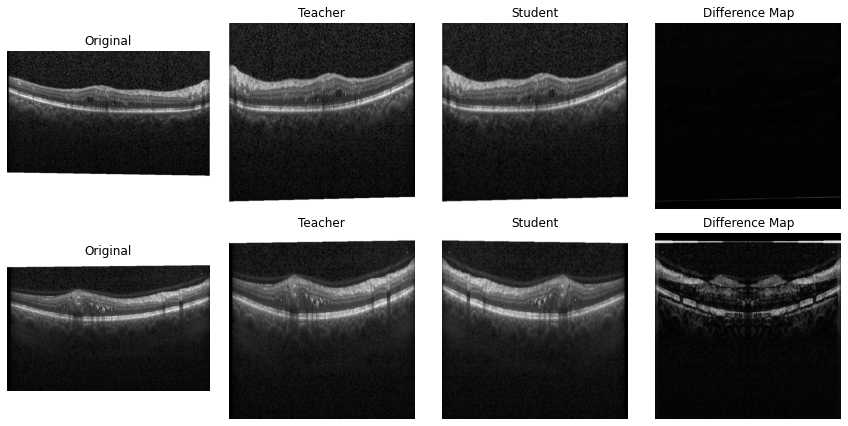

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

imgs_pil_batch, _ = next(iter(test_loader))  # use trainloader

indices = random.sample(range(len(imgs_pil_batch)), 2)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, idx in enumerate(indices):
    img_pil = imgs_pil_batch[idx]

    img_teacher = train_transform(img_pil)
    img_student = train_transform_sub(img_pil)

    img_teacher_dn = denormalize(img_teacher, mean, std)
    img_student_dn = denormalize(img_student, mean, std)

    img_teacher_np = img_teacher_dn.permute(1, 2, 0).numpy()
    img_student_np = img_student_dn.permute(1, 2, 0).numpy()

    img_teacher_np = np.clip(img_teacher_np, 0, 1)
    img_student_np = np.clip(img_student_np, 0, 1)

    # ⭐ Difference map
    diff = np.abs(img_teacher_np - img_student_np)

    axes[row, 0].imshow(img_pil, cmap="gray")
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img_teacher_np, cmap="gray")
    axes[row, 1].set_title("Teacher")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(img_student_np, cmap="gray")
    axes[row, 2].set_title("Student")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(diff, cmap="hot")   # ⭐ KEY VISUALIZATION
    axes[row, 3].set_title("Difference Map")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()


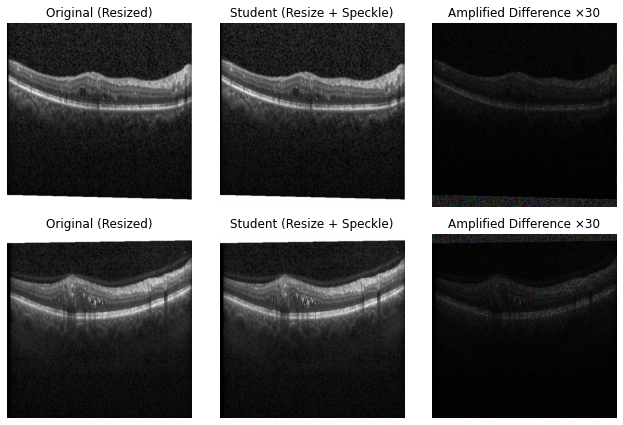

In [69]:
train_transform_sub_vis = transforms.Compose([
    # transforms.Resize((int(0.85 * IMG_SIZE), int(0.85 * IMG_SIZE))),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    AddSpeckleNoise(std=0.01),   # FORCE noise for demo
])
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

AMPLIFY = 30

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

resize_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

for row, idx in enumerate(indices):
    img_pil = imgs_pil_batch[idx]

    # ⭐ Resize original FIRST (CRITICAL FIX)
    img_orig = resize_only(img_pil)
    img_student = train_transform_sub_vis(img_pil)

    orig_np = img_orig.permute(1, 2, 0).numpy()
    student_np = img_student.permute(1, 2, 0).numpy()

    diff = np.abs(orig_np - student_np)
    diff_amp = np.clip(diff * AMPLIFY, 0, 1)

    axes[row, 0].imshow(orig_np, cmap="gray")
    axes[row, 0].set_title("Original (Resized)")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(student_np, cmap="gray")
    axes[row, 1].set_title("Student (Resize + Speckle)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(diff_amp, cmap="hot")
    axes[row, 2].set_title(f"Amplified Difference ×{AMPLIFY}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()


In [53]:
raise Exception

Exception: 

In [ ]:
@torch.no_grad()
def test(
    model,
    loader,
    device,
    criterion,
    test_transform
):
    model.eval()

    probs, targets = [], []
    epoch_loss = 0.0
    
    for imgs_pil, y in tqdm(loader, desc="Test", leave=False):
        y = y.to(device)

        imgs = torch.stack(
            [test_transform(img) for img in imgs_pil]
        ).to(device)

        logits = model.forward_full(imgs)
        loss = criterion(logits, y)

        p = F.softmax(logits, dim=1)

        epoch_loss += loss.item()
        probs.extend(p[:, 1].cpu().numpy())
        targets.extend(y.cpu().numpy())

    epoch_loss /= len(loader)
    
    metrics = compute_binary_metrics(probs, targets)
    acc = np.mean((np.array(probs) >= 0.5) == np.array(targets))
    auc = roc_auc_score(targets, probs)
    uncert = compute_uncertainty_stats(probs, targets)
    
    return epoch_loss, metrics, acc, auc, probs, targets, uncert


In [ ]:
def set_bn_eval(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()
        
def train_head_only(
    model,
    loader,
    optimizer,
    device,
    criterion,
    train_tf_full,
):
    model.train()

    model.apply(set_bn_eval)


    epoch_loss = 0.0
    probs, targets = [], []

    for imgs_pil, y in tqdm(loader, desc="Train", leave=False):
        y = y.to(device)

        imgs = torch.stack(
            [train_tf_full(img) for img in imgs_pil]
        ).to(device)

        optimizer.zero_grad()

        # 🔑 ALWAYS full forward
        logits = model.forward_full(imgs)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        prob = F.softmax(logits, dim=1)[:, 1]
        probs.extend(prob.detach().cpu().numpy())
        targets.extend(y.cpu().numpy())

    epoch_loss /= len(loader)
    auc = roc_auc_score(targets, probs)
    acc = np.mean((np.array(probs) >= 0.5) == np.array(targets))

    return epoch_loss, auc, acc


@torch.no_grad()
def validate_head_only(
    model,
    loader,
    device,
    criterion,
    val_tf,
):
    model.eval()
    model.apply(set_bn_eval)


    epoch_loss = 0.0
    probs, targets = [], []

    for imgs_pil, y in tqdm(loader, desc="Val", leave=False):
        y = y.to(device)

        imgs = torch.stack(
            [val_tf(img) for img in imgs_pil]
        ).to(device)

        logits = model.forward_full(imgs)
        loss = criterion(logits, y)

        epoch_loss += loss.item()

        prob = F.softmax(logits, dim=1)[:, 1]
        probs.extend(prob.cpu().numpy())
        targets.extend(y.cpu().numpy())

    epoch_loss /= len(loader)
    auc = roc_auc_score(targets, probs)
    acc = np.mean((np.array(probs) >= 0.5) == np.array(targets))
    macro_f1 = f1_score(targets, (np.array(probs) >= 0.5).astype(int), average="macro", zero_division=0)

    return epoch_loss, auc, acc, macro_f1



In [ ]:
def aggregate_uncertainty_stats(stats_list):
    if len(stats_list) == 0:
        return {}

    keys = stats_list[0].keys()
    out = {}

    for k in keys:
        vals = [d[k] for d in stats_list]
        out[k] = float(np.mean(vals))

    return out

# Training

In [ ]:
# models_path = "ResNet34_neh_reduced_5e4_GradAug_withjust_with_only_speckle"
# os.makedirs(models_path, exist_ok=True)
# log_file = os.path.join(models_path, "training_log.csv")

# BEST_MACRO_F1 = -1.0
# WARMUP_EPOCHS = 3          # IMPORTANT
# LAMBDA_KL = 0.03

# # checkpoint_path = "/media/miglab/DATA_20TB1/Uncertainty/ResNet34+GradAug_4096_balanced/epoch_2.pth"
# # checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# # model.load_state_dict(checkpoint["state_dict"])
# # model.to(DEVICE)

# for epoch in range(1, NUM_EPOCHS + 1):
#     print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

#     # -------------------------
#     # Train
#     # -------------------------
#     train_loss, train_auc, train_acc = train(
#         model=model,
#         loader=train_loader,
#         optimizer=optimizer,
#         device=DEVICE,
#         criterion=criterion,
#         train_tf_full=train_transform,
#         train_tf_sub=train_transform_sub,
#         epoch=epoch,
#         n_views=2,
#         lambda_kl=LAMBDA_KL,
#         warmup_epochs=WARMUP_EPOCHS
#     )

#     # -------------------------
#     # Validate
#     # -------------------------
#     val_loss, val_metrics, val_acc, val_auc, val_probs, val_targets = validate(
#         model=model,
#         loader=val_loader,
#         device=DEVICE,
#         criterion=criterion,
#         val_transform=val_transform
#     )

#     test_loss, test_metrics, test_acc, test_auc, test_probs, test_targets, test_uncert = test(
#         model=model,
#         loader=test_loader,
#         device=DEVICE,train_loader
#         criterion=criterion,
#         val_transform=test_transform
#     )

#     scheduler.step()

#     # -------------------------
#     # Save checkpoint
#     # -------------------------
#     ckpt = {
#         "epoch": epoch,
#         "state_dict": model.state_dict(),
#         "optimizer": optimizer.state_dict(),
#         "val_auc": val_metrics["roc_auc"]
#     }

#     torch.save(ckpt, os.path.join(models_path, f"epoch_{epoch}.pth"))

#     if val_metrics["macro_f1"] > BEST_MACRO_F1:
#         BEST_MACRO_F1 = val_metrics["macro_f1"]
#         torch.save(ckpt, os.path.join(models_path, "best_model.pth"))

#     # -------------------------
#     # CSV logging
#     # -------------------------
#     row = {
#         "epoch": epoch,
#         "train_loss": train_loss, "val_loss": val_loss, "test_loss": test_loss,
#         "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc,
#         "train_auc": train_auc, "val_auc": val_metrics["roc_auc"], "test_auc": test_metrics["roc_auc"],
#         "val_pr_auc": val_metrics["pr_auc"], "test_pr_auc": test_metrics["pr_auc"], 
#         "val_f1": val_metrics["f1"],  "test_f1": test_metrics["f1"], "val_macro_f1": val_metrics["macro_f1"], "test_macro_f1": test_metrics["macro_f1"],
#         "val_precision": val_metrics["precision"], "val_recall": val_metrics["recall"], "val_npv": val_metrics["npv"],
#         "test_precision": test_metrics["precision"], "test_recall": test_metrics["recall"], "test_npv": test_metrics["npv"],
#         "val_specificity": val_metrics["specificity"], "test_specificity": test_metrics["specificity"], 
#         "val_sens_at_spec_90": val_metrics['sens_at_spec'], "test_sens_at_spec_90": test_metrics['sens_at_spec'],
#         "avg_entropy": test_uncert['avg_entropy'], "entropy_std": test_uncert['entropy_std'],
#         "avg_uncertainty": test_uncert['avg_uncertainty'], "uncertainty_std": test_uncert['uncertainty_std'],
#         "entropy_class0_avg": test_uncert['entropy_class0_avg'], "entropy_class0_std": test_uncert['entropy_class0_std'], "entropy_class1_avg": test_uncert['entropy_class1_avg'], 
#         "entropy_class1_std": test_uncert['entropy_class1_std'], "uncertainty_class0_avg": test_uncert['uncertainty_class0_avg'], "uncertainty_class0_std": test_uncert['uncertainty_class0_std'], 
#         "uncertainty_class1_avg": test_uncert['uncertainty_class1_avg'], "uncertainty_class1_std": test_uncert['uncertainty_class1_std'],
#         "tn": test_metrics["tn"], "fp": test_metrics["fp"], "fn": test_metrics["fn"], "tp": test_metrics["tp"], "n_samples": test_metrics["n_samples"],
#     }

#     append_metrics_to_csv(log_file, row)
    
#     print_epoch_summary(
#         epoch,
#         train_loss,
#         val_loss,
#         test_loss,
#         train_auc,
#         val_auc,
#         test_auc,
#         train_acc,
#         val_acc,
#         test_acc,
#         test_metrics,
#         test_uncert
#     )
    

In [ ]:
models_path = "Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_fintune_dhu"
# models_path = "Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_speckle_fintune_dhu"

os.makedirs(models_path, exist_ok=True)
log_file = os.path.join(models_path, "training_log.csv")

BEST_MACRO_F1 = -1.0
WARMUP_EPOCHS = 3          # IMPORTANT
LAMBDA_KL = 0.03

# checkpoint_path = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/ResNet34_neh_reduced_5e4_GradAug_withjust_resize_Modified_with_speckle/epoch_11.pth"
checkpoint_path = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/ResNet34_neh_reduced_5e4_GradAug_withjust_resize_Modified/epoch_9.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)

BEST_MACRO_F1 = -1.0

NUM_EPOCHS = 20

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,              # higher LR is safe here
    weight_decay=1e-4
)



for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    # -------------------------
    # Train
    # -------------------------
    train_loss, train_auc, train_acc = train_head_only(
        model,
        train_loader,
        optimizer,
        DEVICE,
        criterion,
        train_transform,
    )

    # -------------------------
    # Validate
    # -------------------------

    # -------------------------
    # Validate
    # -------------------------
    val_loss, val_auc, val_acc, val_macro_f1 = validate_head_only(
        model,
        val_loader,
        DEVICE,
        criterion,
        val_transform,
    )

    # test_loss, test_metrics, test_acc, test_auc, test_probs, test_targets, test_uncert = test(
    #     model=model,
    #     loader=test_loader,
    #     device=DEVICE,
    #     criterion=criterion,
    #     val_transform=test_transform
    # )

    scheduler.step()

    # -------------------------
    # Save checkpoint
    # -------------------------
    ckpt = {
        "epoch": epoch,
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "val_auc": val_auc
    }

    torch.save(ckpt, os.path.join(models_path, f"epoch_{epoch}.pth"))

    if val_macro_f1 > BEST_MACRO_F1:
        BEST_MACRO_F1 = val_macro_f1
        torch.save(ckpt, os.path.join(models_path, "best_model.pth"))

    # -------------------------
    # CSV logging
    # -------------------------
    row = {
        "epoch": epoch,
        "train_loss": train_loss, "val_loss": val_loss,
        "train_acc": train_acc, "val_acc": val_acc,
        "train_auc": train_auc, "val_auc": val_auc, 
        "val_macro_f1": val_macro_f1,  "val_macro_f1": val_macro_f1
    }

    append_metrics_to_csv(log_file, row)
    
    print_epoch_summary(
        epoch,
        train_loss,
        val_loss,
        0.0,  # test_loss is not computed in this version
        train_auc,
        val_auc,
        0.0,  # test_auc is not computed in this version
        train_acc,
        val_acc,
        val_macro_f1
    )
    
    


Epoch 1/20


/home/bharath/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1
------------------------------------------------------------------------------------------
Train | Loss=0.3730  AUC=0.9483  Acc=0.8509
Val   | Loss=0.3777  AUC=0.9190  Acc=0.8966
Val Macro F1: 0.8966

Classification Metrics:

Epoch 2/20


Epoch 2
------------------------------------------------------------------------------------------
Train | Loss=0.2688  AUC=0.9498  Acc=0.9211
Val   | Loss=0.4196  AUC=0.9143  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:

Epoch 3/20


Epoch 3
------------------------------------------------------------------------------------------
Train | Loss=0.3179  AUC=0.9433  Acc=0.9211
Val   | Loss=0.4360  AUC=0.9143  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:

Epoch 4/20


...

Epoch 16
------------------------------------------------------------------------------------------
Train | Loss=0.2324  AUC=0.9612  Acc=0.9298
Val   | Loss=0.2646  AUC=0.9238  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:

Epoch 17/20


Epoch 17
------------------------------------------------------------------------------------------
Train | Loss=0.2172  AUC=0.9612  Acc=0.9298
Val   | Loss=0.2581  AUC=0.9286  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:

Epoch 18/20


Epoch 18
------------------------------------------------------------------------------------------
Train | Loss=0.2035  AUC=0.9618  Acc=0.9474
Val   | Loss=0.2535  AUC=0.9286  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:

Epoch 19/20


Epoch 19
------------------------------------------------------------------------------------------
Train | Loss=0.1976  AUC=0.9634  Acc=0.9298
Val   | Loss=0.2514  AUC=0.9286  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:

Epoch 20/20


Epoch 20
------------------------------------------------------------------------------------------
Train | Loss=0.2005  AUC=0.9652  Acc=0.9298
Val   | Loss=0.2490  AUC=0.9286  Acc=0.9310
Val Macro F1: 0.9310

Classification Metrics:


In [ ]:
# raise Exception

# Plots

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import pickle
from PIL import Image, ImageFile
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.isotonic import IsotonicRegression
from typing import Tuple

# =====================================================
# 1. VENN-ABERS CLASS DEFINITION
# =====================================================


class VennAbersBinary:
    def __init__(self):
        self.calib_scores = None
        self.calib_labels = None
        self._fitted = False

    def fit(self, scores: np.ndarray, labels: np.ndarray):
        self.calib_scores = np.asarray(scores, dtype=np.float64)
        self.calib_labels = np.asarray(labels, dtype=np.int32)
        self._fitted = True

    def _fit_isotonic(self, scores, labels):
        ir = IsotonicRegression(out_of_bounds="clip")
        ir.fit(scores, labels)
        return ir

    def predict_interval(self, p: float) -> Tuple[float, float]:
        if not self._fitted:
            raise RuntimeError("Call fit() before predict_interval()")
        scores0 = np.append(self.calib_scores, p)
        labels0 = np.append(self.calib_labels, 0)
        ir0 = self._fit_isotonic(scores0, labels0)
        p0 = float(ir0.predict([p])[0])
        scores1 = np.append(self.calib_scores, p)
        labels1 = np.append(self.calib_labels, 1)
        ir1 = self._fit_isotonic(scores1, labels1)
        p1 = float(ir1.predict([p])[0])
        return min(p0, p1), max(p0, p1)

    def predict(self, p: float, method: str = "mean") -> float:
        p0, p1 = self.predict_interval(p)
        if method == "mean": return 0.5 * (p0 + p1)
        return p0 if method == "lower" else p1

# =====================================================
# 2. PATHS & CONFIG
# =====================================================
# CHECKPOINT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_speckle_fintune_dhu/best_model.pth"
# SAVE_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_speckle_fintune_dhu"
CHECKPOINT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_fintune_dhu/best_model.pth"
SAVE_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_fintune_dhu"
SAVE_PATH = os.path.join(SAVE_DIR, "venn_abers_fitted.pkl")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 512
NUM_CLASSES = 2
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =====================================================
# 3. GRADAUG MODEL DEFINITION
# =====================================================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)
        self.conv1, self.bn1, self.relu, self.maxpool = base.conv1, base.bn1, base.relu, base.maxpool
        self.layer1, self.layer2, self.layer3, self.layer4 = base.layer1, base.layer2, base.layer3, base.layer4
        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# =====================================================
# 5. SCORE EXTRACTION
# =====================================================

print(f"--- Loading GradAug Model: {os.path.basename(CHECKPOINT_PATH)} ---")
model = ResNet34GradAug(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"], strict=True)
model.eval()

val_probs, val_labels = [], []

print("Extracting validation probabilities for calibration...")
with torch.no_grad():
    for imgs_pil, labels in tqdm(val_loader):
        imgs = torch.stack([test_transform(img) for img in imgs_pil]).to(DEVICE)
        logits = model.forward_full(imgs)
        probs = F.softmax(logits, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())


va = VennAbersBinary()
va.fit(scores=np.array(val_probs), labels=np.array(val_labels))

os.makedirs(SAVE_DIR, exist_ok=True)
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(va, f)

print(f"\n--- SUCCESS ---")
print(f"Venn-Abers model saved to: {SAVE_PATH}")

/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


--- Loading GradAug Model: best_model.pth ---
Extracting validation probabilities for calibration...


100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


--- SUCCESS ---
Venn-Abers model saved to: /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_fintune_dhu/venn_abers_fitted.pkl


In [ ]:
from sklearn.metrics import f1_score

f1_macro = f1_score(val_labels, (np.array(val_probs) >= 0.5).astype(int), average="macro")
f1_macro


0.930952380952381

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import pickle
from PIL import Image, ImageFile
from tqdm import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, cohen_kappa_score, fbeta_score
)
from sklearn.isotonic import IsotonicRegression
from typing import Tuple

# =====================================================
# 1. VENN-ABERS CLASS DEFINITION
# =====================================================
class VennAbersBinary:
    def __init__(self):
        self.calib_scores = None
        self.calib_labels = None
        self._fitted = False

    def fit(self, scores: np.ndarray, labels: np.ndarray):
        self.calib_scores = np.asarray(scores, dtype=np.float64)
        self.calib_labels = np.asarray(labels, dtype=np.int32)
        self._fitted = True

    def _fit_isotonic(self, scores, labels):
        ir = IsotonicRegression(out_of_bounds="clip")
        ir.fit(scores, labels)
        return ir

    def predict_interval(self, p: float) -> Tuple[float, float]:
        if not self._fitted:
            raise RuntimeError("Call fit() before predict_interval()")
        scores0 = np.append(self.calib_scores, p)
        labels0 = np.append(self.calib_labels, 0)
        ir0 = self._fit_isotonic(scores0, labels0)
        p0 = float(ir0.predict([p])[0])
        scores1 = np.append(self.calib_scores, p)
        labels1 = np.append(self.calib_labels, 1)
        ir1 = self._fit_isotonic(scores1, labels1)
        p1 = float(ir1.predict([p])[0])
        return min(p0, p1), max(p0, p1)

    def predict(self, p: float, method: str = "mean") -> float:
        p0, p1 = self.predict_interval(p)
        if method == "mean": return 0.5 * (p0 + p1)
        elif method == "lower": return p0
        elif method == "upper": return p1
        else: raise ValueError("method must be 'mean', 'lower', or 'upper'")

    def predict_batch(self, probs: np.ndarray, method: str = "mean") -> np.ndarray:
        probs = np.asarray(probs, dtype=np.float64)
        return np.array([self.predict(p, method=method) for p in probs])


# CHECKPOINT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_speckle_fintune_dhu/best_model.pth"
# VA_PICKLE_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_speckle_fintune_dhu/venn_abers_fitted.pkl"
CHECKPOINT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_fintune_dhu/best_model.pth"
VA_PICKLE_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/Five_percent_20p_ResNet34_neh_reduced_5e4_GradAug_withjust_with_resize_fintune_dhu/venn_abers_fitted.pkl"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 512
NUM_CLASSES = 2
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =====================================================
# 3. METRIC HELPERS
# =====================================================

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp + 1e-8)

def npv_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fn + 1e-8)

def set_size_and_singleton(y_proba, tau=0.9):
    y_proba = np.asarray(y_proba, dtype=np.float64)
    confidence = np.maximum(y_proba, 1.0 - y_proba)
    singleton_mask = confidence >= tau
    set_sizes = np.where(singleton_mask, 1, 2)
    return {
        "avg_set_size": float(np.mean(set_sizes)),
        "singleton_rate": float(np.mean(singleton_mask)) * 100.0,
    }

# def expected_calibration_error(y_true, y_proba, n_bins=10):
#     y_true = np.asarray(y_true, dtype=int)
#     y_proba = np.asarray(y_proba, dtype=np.float64)
#     y_pred = (y_proba >= 0.5).astype(int)
#     confidence = np.where(y_pred == 1, y_proba, 1.0 - y_proba)
#     bins = np.linspace(0.0, 1.0, n_bins + 1)
#     bin_ids = np.digitize(confidence, bins) - 1
#     ece = 0.0
#     for b in range(n_bins):
#         mask = bin_ids == b
#         if not np.any(mask): continue
#         acc_b = np.mean(y_pred[mask] == y_true[mask])
#         conf_b = np.mean(confidence[mask])
#         ece += np.abs(acc_b - conf_b) * np.mean(mask)
#     return float(ece)



def expected_calibration_error(y_true, y_proba, n_bins=15):
    """
    Standard ECE for binary classification (Guo et al., 2017)
    """
    y_true = np.asarray(y_true, dtype=int)
    y_proba = np.asarray(y_proba, dtype=np.float64)

    # Prediction and confidence
    y_pred = (y_proba >= 0.5).astype(int)
    conf = np.maximum(y_proba, 1.0 - y_proba)

    # Bin edges: confidence ∈ [0.5, 1.0]
    bin_edges = np.linspace(0.5, 1.0, n_bins + 1)

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        bin_lower = bin_edges[i]
        bin_upper = bin_edges[i + 1]

        mask = (conf > bin_lower) & (conf <= bin_upper)
        if not np.any(mask):
            continue

        acc_bin = np.mean(y_pred[mask] == y_true[mask])
        conf_bin = np.mean(conf[mask])
        ece += (np.sum(mask) / n) * abs(acc_bin - conf_bin)

    return float(ece)


# =====================================================
# 5. GRADAUG MODEL DEFINITION
# =====================================================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)
        self.conv1, self.bn1, self.relu, self.maxpool = base.conv1, base.bn1, base.relu, base.maxpool
        self.layer1, self.layer2, self.layer3, self.layer4 = base.layer1, base.layer2, base.layer3, base.layer4
        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# =====================================================
# 2. INFERENCE (Using GradAug forward_full & existing test_loader)
# =====================================================
print(f"\n--- Loading GradAug Model: {os.path.basename(CHECKPOINT_PATH)} ---")
# Assuming ResNet34GradAug is already defined as in your snippet
model = ResNet34GradAug(num_classes=2, pretrained=False).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"], strict=True)
model.eval()

with open(VA_PICKLE_PATH, 'rb') as f:
    va = pickle.load(f)

probs_all, labels_all = [], []

with torch.no_grad():
    for imgs_pil, labels in tqdm(test_loader, desc="Inference"):
        imgs = torch.stack([test_transform(img) for img in imgs_pil]).to(DEVICE)
        # Using GradAug's specific full forward pass method
        logits = model.forward_full(imgs)
        probs = F.softmax(logits, dim=1)[:, 1]
        probs_all.extend(probs.cpu().numpy())
        labels_all.extend(labels.numpy())

y_true = np.array(labels_all)
y_prob_raw = np.array(probs_all)

print("\nApplying Venn-Abers Calibration...")
y_prob_va = va.predict_batch(y_prob_raw, method="mean")

# =====================================================
# 3. ORDERED METRICS CALCULATION
# =====================================================
def get_ordered_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    conf_stats = set_size_and_singleton(y_prob, tau=0.9)
    
    # Strictly following the requested order
    return {
        "F1 Macro": f1_score(y_true, y_pred, average="macro"),
        "F2 Macro": fbeta_score(y_true, y_pred, beta=2.0, average="macro", zero_division=0),
        "F2 Weighted": fbeta_score(y_true, y_pred, beta=2.0, average="weighted", zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Specificity": specificity_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro"),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred),
        "NPV": npv_score(y_true, y_pred),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "ECE": expected_calibration_error(y_true, y_prob),
        "Set Size": conf_stats["avg_set_size"],
        "Singleton": conf_stats["singleton_rate"]
    }

metrics_raw = get_ordered_metrics(y_true, y_prob_raw)
metrics_va = get_ordered_metrics(y_true, y_prob_va)

# =====================================================
# 4. FINAL DISPLAY
# =====================================================
print("\n" + "=" * 75)
print(f"GradAug EVALUATION: {os.path.basename(CHECKPOINT_PATH)}")
print("=" * 75)
print(f"{'Metric':<30} | {'Before VA':<15} | {'After VA':<15}")
print("-" * 75)

for key in metrics_raw.keys():
    suffix = "%" if key == "Singleton" else ""
    print(f"{key:<30} | {metrics_raw[key]:<15.4f}{suffix} | {metrics_va[key]:<15.4f}{suffix}")

print("=" * 75)

/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



--- Loading GradAug Model: best_model.pth ---


Inference: 100%|██████████| 86/86 [00:14<00:00,  5.78it/s]



Applying Venn-Abers Calibration...

GradAug EVALUATION: best_model.pth
Metric                         | Before VA       | After VA       
---------------------------------------------------------------------------
F1 Macro                       | 0.9309          | 0.9194         
F2 Macro                       | 0.9310          | 0.9192         
F2 Weighted                    | 0.9309          | 0.9194         
Accuracy                       | 0.9309          | 0.9195         
AUC                            | 0.9767          | 0.9717         
Specificity                    | 0.9402          | 0.8968         
Precision Macro                | 0.9310          | 0.9205         
Recall Macro                   | 0.9311          | 0.9192         
Precision                      | 0.9410          | 0.9043         
Sensitivity                    | 0.9220          | 0.9415         
NPV                            | 0.9209          | 0.9367         
Kappa                          | 0.8619         

# 50 percent results

In [ ]:
# # UCSD only resize 
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9679          | 0.9678         
# F2 Macro                       | 0.9680          | 0.9680         
# F2 Weighted                    | 0.9680          | 0.9679         
# Accuracy                       | 0.9680          | 0.9679         
# AUC                            | 0.9937          | 0.9936         
# Specificity                    | 0.9717          | 0.9734         
# Precision Macro                | 0.9676          | 0.9675         
# Recall Macro                   | 0.9682          | 0.9682         
# Precision                      | 0.9745          | 0.9760         
# Sensitivity                    | 0.9647          | 0.9629         
# NPV                            | 0.9608          | 0.9590         
# Kappa                          | 0.9358          | 0.9356         
# ECE                            | 0.0116          | 0.0047         
# Set Size                       | 1.1262          | 1.0923         
# Singleton                      | 87.3770        % | 90.7668        %
# ===========================================================================

In [ ]:
# # ucsd resize + speckle
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9698          | 0.9696         
# F2 Macro                       | 0.9699          | 0.9698         
# F2 Weighted                    | 0.9699          | 0.9697         
# Accuracy                       | 0.9699          | 0.9697         
# AUC                            | 0.9940          | 0.9939         
# Specificity                    | 0.9729          | 0.9722         
# Precision Macro                | 0.9696          | 0.9695         
# Recall Macro                   | 0.9700          | 0.9699         
# Precision                      | 0.9756          | 0.9750         
# Sensitivity                    | 0.9672          | 0.9676         
# NPV                            | 0.9636          | 0.9639         
# Kappa                          | 0.9396          | 0.9393         
# ECE                            | 0.0123          | 0.0036         
# Set Size                       | 1.1218          | 1.0722         
# Singleton                      | 87.8192        % | 92.7803        %
# ===========================================================================

In [ ]:
# DHU resize + speckle

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9808          | 0.9686         
# F2 Macro                       | 0.9815          | 0.9697         
# F2 Weighted                    | 0.9808          | 0.9684         
# Accuracy                       | 0.9809          | 0.9686         
# AUC                            | 0.9976          | 0.9977         
# Specificity                    | 0.9971          | 1.0000         
# Precision Macro                | 0.9802          | 0.9683         
# Recall Macro                   | 0.9820          | 0.9708         
# Precision                      | 0.9974          | 1.0000         
# Sensitivity                    | 0.9670          | 0.9416         
# NPV                            | 0.9630          | 0.9366         
# Kappa                          | 0.9617          | 0.9372         
# ECE                            | 0.0395          | 0.0205         
# Set Size                       | 1.1821          | 1.1057         
# Singleton                      | 81.7872        % | 89.4270        %
# ===========================================================================

In [ ]:
# # DHU resize only
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9726          | 0.9468         
# F2 Macro                       | 0.9734          | 0.9483         
# F2 Weighted                    | 0.9726          | 0.9462         
# Accuracy                       | 0.9727          | 0.9468         
# AUC                            | 0.9959          | 0.9959         
# Specificity                    | 0.9912          | 1.0000         
# Precision Macro                | 0.9720          | 0.9485         
# Recall Macro                   | 0.9740          | 0.9504         
# Precision                      | 0.9921          | 1.0000         
# Sensitivity                    | 0.9568          | 0.9009         
# NPV                            | 0.9519          | 0.8970         
# Kappa                          | 0.9453          | 0.8938         
# ECE                            | 0.0242          | 0.0369         
# Set Size                       | 1.1508          | 1.1064         
# Singleton                      | 84.9250        % | 89.3588        %
# ===========================================================================

In [ ]:
# # oct c8 resize + speckle

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9473          | 0.9494         
# F2 Macro                       | 0.9477          | 0.9499         
# F2 Weighted                    | 0.9472          | 0.9492         
# Accuracy                       | 0.9473          | 0.9494         
# AUC                            | 0.9884          | 0.9881         
# Specificity                    | 0.9656          | 0.9758         
# Precision Macro                | 0.9471          | 0.9496         
# Recall Macro                   | 0.9481          | 0.9506         
# Precision                      | 0.9674          | 0.9768         
# Sensitivity                    | 0.9307          | 0.9253         
# NPV                            | 0.9269          | 0.9224         
# Kappa                          | 0.8946          | 0.8988         
# ECE                            | 0.0284          | 0.0160         
# Set Size                       | 1.2558          | 1.1606         
# Singleton                      | 74.4154        % | 83.9442        %
# ===========================================================================

In [ ]:
# # oct c8 resize only

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9483          | 0.9479         
# F2 Macro                       | 0.9484          | 0.9478         
# F2 Weighted                    | 0.9483          | 0.9480         
# Accuracy                       | 0.9483          | 0.9480         
# AUC                            | 0.9894          | 0.9893         
# Specificity                    | 0.9524          | 0.9436         
# Precision Macro                | 0.9481          | 0.9479         
# Recall Macro                   | 0.9485          | 0.9478         
# Precision                      | 0.9561          | 0.9488         
# Sensitivity                    | 0.9447          | 0.9520         
# NPV                            | 0.9400          | 0.9471         
# Kappa                          | 0.8965          | 0.8957         
# ECE                            | 0.0319          | 0.0138         
# Set Size                       | 1.2663          | 1.1756         
# Singleton                      | 73.3682        % | 82.4433        %
# ===========================================================================

# 10 percent results 20 epochs

In [ ]:
# # UCSD speckle + resize
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9577          | 0.9588         
# F2 Macro                       | 0.9574          | 0.9585         
# F2 Weighted                    | 0.9578          | 0.9589         
# Accuracy                       | 0.9579          | 0.9589         
# AUC                            | 0.9915          | 0.9915         
# Specificity                    | 0.9436          | 0.9474         
# Precision Macro                | 0.9585          | 0.9593         
# Recall Macro                   | 0.9573          | 0.9584         
# Precision                      | 0.9495          | 0.9526         
# Sensitivity                    | 0.9709          | 0.9694         
# NPV                            | 0.9675          | 0.9660         
# Kappa                          | 0.9155          | 0.9175         
# ECE                            | 0.0135          | 0.0147         
# Set Size                       | 1.1685          | 1.1134         
# Singleton                      | 83.1498        % | 88.6637        %
# ===========================================================================

In [ ]:
# # UCSD resize
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9563          | 0.9563         
# F2 Macro                       | 0.9562          | 0.9562         
# F2 Weighted                    | 0.9564          | 0.9564         
# Accuracy                       | 0.9564          | 0.9564         
# AUC                            | 0.9906          | 0.9905         
# Specificity                    | 0.9486          | 0.9493         
# Precision Macro                | 0.9566          | 0.9566         
# Recall Macro                   | 0.9561          | 0.9561         
# Precision                      | 0.9534          | 0.9540         
# Sensitivity                    | 0.9636          | 0.9630         
# NPV                            | 0.9598          | 0.9592         
# Kappa                          | 0.9126          | 0.9127         
# ECE                            | 0.0114          | 0.0118         
# Set Size                       | 1.1667          | 1.0967         
# Singleton                      | 83.3298        % | 90.3268        %
# ===========================================================================

In [ ]:
# # DHU speckle + resize

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9345          | 0.9302         
# F2 Macro                       | 0.9340          | 0.9294         
# F2 Weighted                    | 0.9343          | 0.9297         
# Accuracy                       | 0.9347          | 0.9305         
# AUC                            | 0.9805          | 0.9799         
# Specificity                    | 0.9744          | 0.9860         
# Precision Macro                | 0.9377          | 0.9362         
# Recall Macro                   | 0.9343          | 0.9300         
# Precision                      | 0.9717          | 0.9839         
# Sensitivity                    | 0.8941          | 0.8739         
# NPV                            | 0.9037          | 0.8886         
# Kappa                          | 0.8692          | 0.8608         
# ECE                            | 0.0309          | 0.0509         
# Set Size                       | 1.1115          | 1.0529         
# Singleton                      | 88.8473        % | 94.7149        %
# ===========================================================================

In [ ]:
# # DHU resize
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9262          | 0.9158         
# F2 Macro                       | 0.9257          | 0.9147         
# F2 Weighted                    | 0.9260          | 0.9151         
# Accuracy                       | 0.9263          | 0.9164         
# AUC                            | 0.9648          | 0.9662         
# Specificity                    | 0.9646          | 0.9852         
# Precision Macro                | 0.9291          | 0.9248         
# Recall Macro                   | 0.9260          | 0.9157         
# Precision                      | 0.9609          | 0.9824         
# Sensitivity                    | 0.8874          | 0.8462         
# NPV                            | 0.8972          | 0.8672         
# Kappa                          | 0.8526          | 0.8325         
# ECE                            | 0.0360          | 0.0584         
# Set Size                       | 1.1590          | 1.0728         
# Singleton                      | 84.1032        % | 92.7174        %
# ===========================================================================

In [ ]:
# # oct c8 spekle + resize

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9182          | 0.9172         
# F2 Macro                       | 0.9189          | 0.9177         
# F2 Weighted                    | 0.9177          | 0.9171         
# Accuracy                       | 0.9182          | 0.9172         
# AUC                            | 0.9707          | 0.9703         
# Specificity                    | 0.9605          | 0.9398         
# Precision Macro                | 0.9199          | 0.9173         
# Recall Macro                   | 0.9201          | 0.9182         
# Precision                      | 0.9608          | 0.9424         
# Sensitivity                    | 0.8796          | 0.8967         
# NPV                            | 0.8790          | 0.8922         
# Kappa                          | 0.8367          | 0.8344         
# ECE                            | 0.0142          | 0.0360         
# Set Size                       | 1.2978          | 1.3165         
# Singleton                      | 70.2152        % | 68.3537        %
# ===========================================================================


In [ ]:
# # oct c8 resize
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9185          | 0.9183         
# F2 Macro                       | 0.9188          | 0.9185         
# F2 Weighted                    | 0.9185          | 0.9184         
# Accuracy                       | 0.9186          | 0.9184         
# AUC                            | 0.9703          | 0.9693         
# Specificity                    | 0.9292          | 0.9251         
# Precision Macro                | 0.9183          | 0.9180         
# Recall Macro                   | 0.9190          | 0.9187         
# Precision                      | 0.9338          | 0.9305         
# Sensitivity                    | 0.9089          | 0.9122         
# NPV                            | 0.9027          | 0.9056         
# Kappa                          | 0.8370          | 0.8365         
# ECE                            | 0.0364          | 0.0158         
# Set Size                       | 1.3805          | 1.3264         
# Singleton                      | 61.9546        % | 67.3647        %
# ===========================================================================

# 5 percent Results

In [ ]:
# # oct c8 speckle + resize

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.8990          | 0.9003         
# F2 Macro                       | 0.8991          | 0.9005         
# F2 Weighted                    | 0.8991          | 0.9004         
# Accuracy                       | 0.8991          | 0.9004         
# AUC                            | 0.9572          | 0.9566         
# Specificity                    | 0.8997          | 0.9044         
# Precision Macro                | 0.8988          | 0.9001         
# Recall Macro                   | 0.8992          | 0.9006         
# Precision                      | 0.9078          | 0.9116         
# Sensitivity                    | 0.8986          | 0.8968         
# NPV                            | 0.8898          | 0.8886         
# Kappa                          | 0.7979          | 0.8006         
# ECE                            | 0.0160          | 0.0416         
# Set Size                       | 1.2903          | 1.2396         
# Singleton                      | 70.9719        % | 76.0426        %
# ===========================================================================

In [ ]:
# # oct c8 resize

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.8811          | 0.8859         
# F2 Macro                       | 0.8811          | 0.8867         
# F2 Weighted                    | 0.8813          | 0.8853         
# Accuracy                       | 0.8813          | 0.8859         
# AUC                            | 0.9481          | 0.9472         
# Specificity                    | 0.8762          | 0.9375         
# Precision Macro                | 0.8810          | 0.8889         
# Recall Macro                   | 0.8811          | 0.8882         
# Precision                      | 0.8872          | 0.9365         
# Sensitivity                    | 0.8860          | 0.8389         
# NPV                            | 0.8749          | 0.8412         
# Kappa                          | 0.7621          | 0.7725         
# ECE                            | 0.0206          | 0.0443         
# Set Size                       | 1.3257          | 1.3076         
# Singleton                      | 67.4261        % | 69.2449        %
# ===========================================================================


In [ ]:
# # DHU speckle + resize
# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9526          | 0.9555         
# F2 Macro                       | 0.9525          | 0.9556         
# F2 Weighted                    | 0.9526          | 0.9555         
# Accuracy                       | 0.9526          | 0.9555         
# AUC                            | 0.9889          | 0.9869         
# Specificity                    | 0.9476          | 0.9596         
# Precision Macro                | 0.9527          | 0.9555         
# Recall Macro                   | 0.9525          | 0.9556         
# Precision                      | 0.9499          | 0.9606         
# Sensitivity                    | 0.9574          | 0.9516         
# NPV                            | 0.9555          | 0.9504         
# Kappa                          | 0.9052          | 0.9111         
# ECE                            | 0.0428          | 0.1054         
# Set Size                       | 1.2866          | 1.5470         
# Singleton                      | 71.3446        % | 45.2976        %
# ===========================================================================

In [ ]:
# # DHU resize only

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9309          | 0.9194         
# F2 Macro                       | 0.9310          | 0.9192         
# F2 Weighted                    | 0.9309          | 0.9194         
# Accuracy                       | 0.9309          | 0.9195         
# AUC                            | 0.9767          | 0.9717         
# Specificity                    | 0.9402          | 0.8968         
# Precision Macro                | 0.9310          | 0.9205         
# Recall Macro                   | 0.9311          | 0.9192         
# Precision                      | 0.9410          | 0.9043         
# Sensitivity                    | 0.9220          | 0.9415         
# NPV                            | 0.9209          | 0.9367         
# Kappa                          | 0.8619          | 0.8389         
# ECE                            | 0.0171          | 0.0992         
# Set Size                       | 1.2388          | 1.6954         
# Singleton                      | 76.1205        % | 30.4555        %
# ===========================================================================

In [ ]:
# # UCSD speckle + resize

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9563          | 0.9553         
# F2 Macro                       | 0.9563          | 0.9552         
# F2 Weighted                    | 0.9564          | 0.9555         
# Accuracy                       | 0.9564          | 0.9555         
# AUC                            | 0.9890          | 0.9888         
# Specificity                    | 0.9564          | 0.9487         
# Precision Macro                | 0.9562          | 0.9556         
# Recall Macro                   | 0.9564          | 0.9551         
# Precision                      | 0.9605          | 0.9540         
# Sensitivity                    | 0.9563          | 0.9616         
# NPV                            | 0.9518          | 0.9571         
# Kappa                          | 0.9125          | 0.9107         
# ECE                            | 0.0173          | 0.0105         
# Set Size                       | 1.1842          | 1.0736         
# Singleton                      | 81.5841        % | 92.6435        %
# ===========================================================================

In [ ]:
# # UCSD resize

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9517          | 0.9521         
# F2 Macro                       | 0.9519          | 0.9521         
# F2 Weighted                    | 0.9517          | 0.9523         
# Accuracy                       | 0.9517          | 0.9523         
# AUC                            | 0.9886          | 0.9882         
# Specificity                    | 0.9611          | 0.9496         
# Precision Macro                | 0.9514          | 0.9521         
# Recall Macro                   | 0.9522          | 0.9521         
# Precision                      | 0.9641          | 0.9545         
# Sensitivity                    | 0.9433          | 0.9546         
# NPV                            | 0.9386          | 0.9498         
# Kappa                          | 0.9033          | 0.9043         
# ECE                            | 0.0085          | 0.0097         
# Set Size                       | 1.1699          | 1.1141         
# Singleton                      | 83.0072        % | 88.5933        %
# ===========================================================================

# 10 percent Results

In [ ]:
# Applying Venn-Abers Calibration...
# 20 epochs finetune only resize
# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9185          | 0.9183         
# F2 Macro                       | 0.9188          | 0.9185         
# F2 Weighted                    | 0.9185          | 0.9184         
# Accuracy                       | 0.9186          | 0.9184         
# AUC                            | 0.9703          | 0.9693         
# Specificity                    | 0.9292          | 0.9251         
# Precision Macro                | 0.9183          | 0.9180         
# Recall Macro                   | 0.9190          | 0.9187         
# Precision                      | 0.9338          | 0.9305         
# Sensitivity                    | 0.9089          | 0.9122         
# NPV                            | 0.9027          | 0.9056         
# Kappa                          | 0.8370          | 0.8365         
# ECE                            | 0.0361          | 0.0142         
# Set Size                       | 1.3805          | 1.3264         
# Singleton                      | 61.9546        % | 67.3647        %

In [ ]:
# resize and speckle OCT c8

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9077          | 0.8833         
# F2 Macro                       | 0.9083          | 0.8816         
# F2 Weighted                    | 0.9074          | 0.8836         
# Accuracy                       | 0.9077          | 0.8846         
# AUC                            | 0.9654          | 0.9645         
# Specificity                    | 0.9442          | 0.8177         
# Precision Macro                | 0.9088          | 0.8913         
# Recall Macro                   | 0.9093          | 0.8816         
# Precision                      | 0.9452          | 0.8507         
# Sensitivity                    | 0.8744          | 0.9456         
# NPV                            | 0.8725          | 0.9318         
# Kappa                          | 0.8157          | 0.7675         
# ECE                            | 0.0244          | 0.0422         
# Set Size                       | 1.3739          | 1.3027         
# Singleton                      | 62.6139        % | 69.7305        %
# ===========================================================================

In [ ]:
# only Resize OCT c8

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9005          | 0.8858         
# F2 Macro                       | 0.9013          | 0.8848         
# F2 Weighted                    | 0.8998          | 0.8861         
# Accuracy                       | 0.9005          | 0.8866         
# AUC                            | 0.9593          | 0.9580         
# Specificity                    | 0.9569          | 0.8425         
# Precision Macro                | 0.9041          | 0.8894         
# Recall Macro                   | 0.9031          | 0.8846         
# Precision                      | 0.9558          | 0.8660         
# Sensitivity                    | 0.8493          | 0.9267         
# NPV                            | 0.8524          | 0.9127         
# Kappa                          | 0.8017          | 0.7718         
# ECE                            | 0.0377          | 0.0150         
# Set Size                       | 1.4400          | 1.3777         
# Singleton                      | 56.0016        % | 62.2261        %
# ===========================================================================

In [ ]:
# resize and speckle UCSD

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9551          | 0.9550         
# F2 Macro                       | 0.9553          | 0.9551         
# F2 Weighted                    | 0.9552          | 0.9551         
# Accuracy                       | 0.9552          | 0.9551         
# AUC                            | 0.9897          | 0.9895         
# Specificity                    | 0.9628          | 0.9582         
# Precision Macro                | 0.9549          | 0.9549         
# Recall Macro                   | 0.9555          | 0.9552         
# Precision                      | 0.9653          | 0.9613         
# Sensitivity                    | 0.9482          | 0.9522         
# NPV                            | 0.9446          | 0.9484         
# Kappa                          | 0.9103          | 0.9100         
# ECE                            | 0.0014          | 0.0051         
# Set Size                       | 1.1350          | 1.1274         
# Singleton                      | 86.4993        % | 87.2613        %
# ===========================================================================

In [ ]:
# only Resize UCSD

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9499          | 0.9488         
# F2 Macro                       | 0.9503          | 0.9486         
# F2 Weighted                    | 0.9499          | 0.9489         
# Accuracy                       | 0.9499          | 0.9489         
# AUC                            | 0.9878          | 0.9877         
# Specificity                    | 0.9660          | 0.9395         
# Precision Macro                | 0.9498          | 0.9491         
# Recall Macro                   | 0.9506          | 0.9485         
# Precision                      | 0.9677          | 0.9453         
# Sensitivity                    | 0.9352          | 0.9576         
# NPV                            | 0.9318          | 0.9530         
# Kappa                          | 0.8999          | 0.8976         
# ECE                            | 0.0146          | 0.0094         
# Set Size                       | 1.1958          | 1.1061         
# Singleton                      | 80.4245        % | 89.3906        %
# ===========================================================================

In [ ]:
# resize and speckle DHU


# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9345          | 0.9302         
# F2 Macro                       | 0.9340          | 0.9294         
# F2 Weighted                    | 0.9343          | 0.9297         
# Accuracy                       | 0.9347          | 0.9305         
# AUC                            | 0.9805          | 0.9799         
# Specificity                    | 0.9744          | 0.9860         
# Precision Macro                | 0.9377          | 0.9362         
# Recall Macro                   | 0.9343          | 0.9300         
# Precision                      | 0.9717          | 0.9839         
# Sensitivity                    | 0.8941          | 0.8739         
# NPV                            | 0.9037          | 0.8886         
# Kappa                          | 0.8692          | 0.8608         
# ECE                            | 0.0298          | 0.0480         
# Set Size                       | 1.1115          | 1.0529         
# Singleton                      | 88.8473        % | 94.7149        %
# ===========================================================================

In [ ]:
# only Resize DHU

# Applying Venn-Abers Calibration...

# ===========================================================================
# GradAug EVALUATION: best_model.pth
# ===========================================================================
# Metric                         | Before VA       | After VA       
# ---------------------------------------------------------------------------
# F1 Macro                       | 0.9315          | 0.9315         
# F2 Macro                       | 0.9310          | 0.9310         
# F2 Weighted                    | 0.9312          | 0.9312         
# Accuracy                       | 0.9318          | 0.9318         
# AUC                            | 0.9722          | 0.9737         
# Specificity                    | 0.9769          | 0.9769         
# Precision Macro                | 0.9356          | 0.9356         
# Recall Macro                   | 0.9313          | 0.9313         
# Precision                      | 0.9741          | 0.9741         
# Sensitivity                    | 0.8857          | 0.8857         
# NPV                            | 0.8970          | 0.8970         
# Kappa                          | 0.8634          | 0.8634         
# ECE                            | 0.0173          | 0.0450         
# Set Size                       | 1.1819          | 1.0682         
# Singleton                      | 81.8144        % | 93.1752        %
# ===========================================================================

In [ ]:
# import os
# import torch
# import numpy as np
# import pandas as pd
# import pickle
# from PIL import Image, ImageFile
# from tqdm import tqdm
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader
# from torchvision import models, transforms
# from sklearn.isotonic import IsotonicRegression
# from typing import Tuple

# # =====================================================
# # 1. VENN-ABERS CLASS DEFINITION
# # =====================================================


# class VennAbersBinary:
#     def __init__(self):
#         self.calib_scores = None
#         self.calib_labels = None
#         self._fitted = False

#     def fit(self, scores: np.ndarray, labels: np.ndarray):
#         self.calib_scores = np.asarray(scores, dtype=np.float64)
#         self.calib_labels = np.asarray(labels, dtype=np.int32)
#         self._fitted = True

#     def _fit_isotonic(self, scores, labels):
#         ir = IsotonicRegression(out_of_bounds="clip")
#         ir.fit(scores, labels)
#         return ir

#     def predict_interval(self, p: float) -> Tuple[float, float]:
#         if not self._fitted:
#             raise RuntimeError("Call fit() before predict_interval()")
#         scores0 = np.append(self.calib_scores, p)
#         labels0 = np.append(self.calib_labels, 0)
#         ir0 = self._fit_isotonic(scores0, labels0)
#         p0 = float(ir0.predict([p])[0])
#         scores1 = np.append(self.calib_scores, p)
#         labels1 = np.append(self.calib_labels, 1)
#         ir1 = self._fit_isotonic(scores1, labels1)
#         p1 = float(ir1.predict([p])[0])
#         return min(p0, p1), max(p0, p1)

#     def predict(self, p: float, method: str = "mean") -> float:
#         p0, p1 = self.predict_interval(p)
#         if method == "mean": return 0.5 * (p0 + p1)
#         return p0 if method == "lower" else p1

# # =====================================================
# # 2. PATHS & CONFIG
# # =====================================================
# CHECKPOINT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/ResNet34_neh_reduced_5e4_GradAug_withjust_resize_Modified/epoch_9.pth"
# VAL_CSV_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_val_reduced.csv"
# SAVE_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/ResNet34_neh_reduced_5e4_GradAug_withjust_resize_Modified"
# SAVE_PATH = os.path.join(SAVE_DIR, "venn_abers_fitted.pkl")

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BATCH_SIZE = 32
# IMG_SIZE = 512
# NUM_CLASSES = 2
# ImageFile.LOAD_TRUNCATED_IMAGES = True

# # =====================================================
# # 3. GRADAUG MODEL DEFINITION
# # =====================================================
# class ResNet34GradAug(nn.Module):
#     def __init__(self, num_classes=2, pretrained=False):
#         super().__init__()
#         base = models.resnet34(pretrained=pretrained)
#         self.conv1, self.bn1, self.relu, self.maxpool = base.conv1, base.bn1, base.relu, base.maxpool
#         self.layer1, self.layer2, self.layer3, self.layer4 = base.layer1, base.layer2, base.layer3, base.layer4
#         self.avgpool = base.avgpool
#         self.fc = nn.Linear(512, num_classes)

#     def forward_full(self, x):
#         x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
#         x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         return self.fc(x)

# # =====================================================
# # 4. DATASET & LOADER
# # =====================================================
# class UCSDDataset(Dataset):
#     def __init__(self, csv_path):
#         self.df = pd.read_csv(csv_path)
#     def __len__(self): return len(self.df)
#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         img = Image.open(row["new_file_path"]).convert("RGB")
#         label = int(row["binary_label"])
#         return img, label

# def pil_collate_fn(batch):
#     imgs, labels = zip(*batch)
#     return list(imgs), torch.tensor(labels, dtype=torch.long)

# test_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# loader = DataLoader(UCSDDataset(VAL_CSV_PATH), batch_size=BATCH_SIZE, shuffle=False, num_workers=4, collate_fn=pil_collate_fn)

# # =====================================================
# # 5. SCORE EXTRACTION
# # =====================================================
# print(f"--- Loading GradAug Model: {os.path.basename(CHECKPOINT_PATH)} ---")
# model = ResNet34GradAug(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
# ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
# model.load_state_dict(ckpt["state_dict"], strict=True)
# model.eval()

# val_probs, val_labels = [], []

# print("Extracting validation probabilities for calibration...")
# with torch.no_grad():
#     for imgs_pil, labels in tqdm(loader):
#         imgs = torch.stack([test_transform(img) for img in imgs_pil]).to(DEVICE)
#         logits = model.forward_full(imgs)
#         probs = F.softmax(logits, dim=1)[:, 1]
#         val_probs.extend(probs.cpu().numpy())
#         val_labels.extend(labels.numpy())

# # =====================================================
# # 6. FIT & SAVE
# # =====================================================
# va = VennAbersBinary()
# va.fit(scores=np.array(val_probs), labels=np.array(val_labels))

# os.makedirs(SAVE_DIR, exist_ok=True)
# with open(SAVE_PATH, 'wb') as f:
#     pickle.dump(va, f)

# print(f"\n--- SUCCESS ---")
# print(f"Venn-Abers model saved to: {SAVE_PATH}")